Answer Synthesis from Multiple Sources

In [1]:
import os
from typing import List
from pydantic import BaseModel
from langchain.chat_models import init_chat_model
from langchain_core.documents import Document
from langchain_community.vectorstores import FAISS
from langchain_community.document_loaders import TextLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langgraph.graph import StateGraph,END
from langchain_community.document_loaders.youtube import YoutubeLoader
from langchain_community.document_loaders import ArxivLoader

initializing the LLM

In [2]:
llm = init_chat_model("groq:llama-3.1-8b-instant")
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.4.8', 'langchain': '1.3.11'}}, output_version=None, profile={'name': 'Llama 3.1 8B Instant', 'release_date': '2024-07-23', 'last_updated': '2024-07-23', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 131072, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x000001AC992FEF30>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001AC99932390>, model_name='llama-3.1-8b-instant', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [3]:
from langchain_huggingface import HuggingFaceEmbeddings
embedding = HuggingFaceEmbeddings(model="all-MiniLM-L6-v2")
embedding

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

HuggingFaceEmbeddings(model_name='all-MiniLM-L6-v2', cache_folder=None, model_kwargs={}, encode_kwargs={}, query_encode_kwargs={}, multi_process=False, show_progress=False)

fncs used for building Nodes

In [4]:
def load_text_retriever(file_path: str):
    docs = TextLoader(file_path,encoding="utf-8").load()
    splitter = RecursiveCharacterTextSplitter(chunk_size=500,chunk_overlap=50)
    chunks = splitter.split_documents(docs)
    vs = FAISS.from_documents(chunks,embedding)
    return vs.as_retriever()

def load_youtube_retriever():
    # mock transcript
    content = """
    One of the biggest misconceptions about Retrieval-Augmented Generation, or RAG, is that the language model does all the work. In reality, retrieval quality is just as important. Take a system like Project Nova—it relies on the embed-v5 embedding model to search a knowledge base of over 124 GB containing around 1.6 million indexed documents before generating an answer. Even with an answer accuracy close to 89% and an average retrieval latency of about 72 milliseconds, engineers still continuously benchmark performance because even small index updates can slightly reduce retrieval quality. That's why production RAG systems focus not only on the model itself but also on monitoring latency, validating production metrics, and comparing new results against previous baselines to ensure users consistently receive accurate and relevant responses.
    """
    doc = Document(page_content=content, metadata={"source": "youtube"})
    vectorstore = FAISS.from_documents([doc], embedding)
    return vectorstore.as_retriever()

def arxiv_search(query: str) -> str:
    results = ArxivLoader(query).load()
    return "\n\n".join(doc.page_content for doc in results[:2]) or "No relevant papers found."


In [5]:
text_retriever = load_text_retriever("research_notes.txt")
yt_retriever = load_youtube_retriever()

State Definiton

In [7]:
class RAGState(BaseModel):
    question: str
    text_docs: List[Document] = []
    yt_docs: List[Document] = []
    arxiv_context: str = ""
    final_answer: str = ""

Node Definitions

In [12]:
def retrieve_text(state: RAGState) -> RAGState:
    docs = text_retriever.invoke(state.question)
    return state.model_copy(update={"text_docs":docs})

def retrieve_yt(state: RAGState) -> RAGState:
    docs = yt_retriever.invoke(state.question)
    return state.model_copy(update={"yt_docs": docs})

def retrieve_arxiv(state: RAGState) -> RAGState:
    result = arxiv_search(state.question)
    print(result)
    return state.model_copy(update={"arxiv_context": result})

synthesizer node

In [9]:
def synthesize_answer(state: RAGState) -> RAGState:
    context = ""

    context += "\n\n[Internal Docs]\n" + "\n".join([doc.page_content for doc in state.text_docs])
    context += "\n\n[YouTube Transcript]\n" + "\n".join([doc.page_content for doc in state.yt_docs])
    context += "\n\n[ArXiv]\n" + state.arxiv_context

    prompt = f"""You have retrieved relevant context from multiple sources. Now synthesize a complete and coherent answer.
    Question: {state.question}
    Context:
    {context}
    Final Answer:"""

    answer = llm.invoke(prompt).content.strip()
    return state.model_copy(update={"final_answer": answer})

building the graph

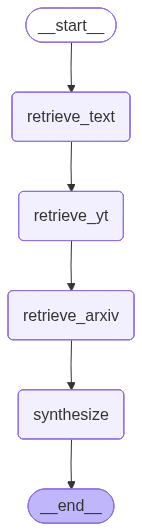

In [10]:
builder = StateGraph(RAGState)

builder.add_node("retrieve_text", retrieve_text)
builder.add_node("retrieve_yt", retrieve_yt)
builder.add_node("retrieve_arxiv", retrieve_arxiv)
builder.add_node("synthesize", synthesize_answer)

builder.set_entry_point("retrieve_text")
builder.add_edge("retrieve_text", "retrieve_yt")
builder.add_edge("retrieve_yt", "retrieve_arxiv")
builder.add_edge("retrieve_arxiv", "synthesize")
builder.add_edge("synthesize", END)

graph = builder.compile()
graph

testing answer synthesis

In [13]:
question = "How does Project Nova's RAG pipeline use embeddings for document retrieval, what production metrics are used to evaluate its performance, and why do research papers recommend benchmarking retrieval quality separately from generation quality?"
state = RAGState(question=question)
result = graph.invoke(state)

print("Final Answer:\n")
print(result["final_answer"])

AttributeError: 'Search' object has no attribute 'results'